# NBA Win Probability Phase 1: Data Pipeline & Feature Engineering

**Goal:** Pull 6 seasons of NBA game + play-by-play data, compute Elo ratings, engineer features, validate data quality, and export GPU-ready tensors.


### Pipeline Overview
```
1. Environment & GPU Setup
2. Config & Directory Structure  
3. Pull Historical Game Logs (6 seasons)
4. Compute Elo Ratings
5. Pull Play-by-Play Data (batched + resumable)
6. Feature Engineering
7. Statistical Validation & Data Quality Tests
8. Build Tensors → Push to GPU → Save
```

##  Install Dependencies

In [51]:
# Run once — comment out after first execution
import subprocess, sys

packages = [
    'nba_api',
    'pandas',
    'numpy',
    'scipy',
    'scikit-learn',
    'tqdm',
    'matplotlib',
    'seaborn',
    'pyarrow',   # fast parquet I/O
    'requests',
    'torch',
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print(' All packages installed')

 All packages installed


## GPU Verification & Environment Setup

In [52]:
import torch
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# GPU check 
print('=' * 60)
print('ENVIRONMENT CHECK')
print('=' * 60)
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')

if not torch.cuda.is_available():
    raise RuntimeError(
        'CUDA not available. '
        'Ensure PyTorch cu124 is installed and the RTX 4060 driver is active.'
    )

DEVICE = torch.device('cuda')
gpu     = torch.cuda.get_device_properties(0)
vram_gb = gpu.total_memory / 1e9

print(f'Device          : {gpu.name}')
print(f'VRAM            : {vram_gb:.1f} GB')
print(f'CUDA version    : {torch.version.cuda}')
print(f'cuDNN version   : {torch.backends.cudnn.version()}')
print(f'Compute cap.    : {gpu.major}.{gpu.minor}')
print('=' * 60)

# Warm up GPU with a small tensor op to verify driver is responsive
_t = torch.randn(1024, 1024, device=DEVICE)
_  = torch.mm(_t, _t)
torch.cuda.synchronize()
del _t, _
print(f' GPU warm-up passed — DEVICE = {DEVICE}')

ENVIRONMENT CHECK
PyTorch version : 2.6.0+cu124
CUDA available  : True
Device          : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM            : 8.6 GB
CUDA version    : 12.4
cuDNN version   : 90100
Compute cap.    : 8.9
 GPU warm-up passed — DEVICE = cuda


## Configuration

In [53]:
import os
from pathlib import Path

#  Paths 
BASE_DIR   = Path('nba_win_prob')
RAW_DIR    = BASE_DIR / 'raw'
PBP_DIR    = RAW_DIR  / 'pbp'          # one parquet per game
PROC_DIR   = BASE_DIR / 'processed'
MODEL_DIR  = BASE_DIR / 'model'

for d in [RAW_DIR, PBP_DIR, PROC_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

#  Seasons to pull (format nba_api uses) 
# 2018-19 → 2023-24  (6 seasons = ~7,500 regular season + ~400 playoff games)
SEASONS = [
    '2018-19',
    '2019-20',
    '2020-21',
    '2021-22',
    '2022-23',
    '2023-24',
]

#  Elo hyperparameters 
ELO_START      = 1500     # initial Elo for every team
ELO_K          = 20       # update factor per game
ELO_REVERT     = 0.35     # season-start regression toward 1500 (35 %)
HOME_ADVANTAGE = 100      # Elo points added for home court

# nba_api rate limiting 
API_SLEEP      = 0.65     # seconds between requests (nba_api allows ~100/min)
API_RETRY      = 3        # retries on timeout
API_TIMEOUT    = 30       # seconds

# Feature config 
FEATURE_COLS = [
    'score_diff',          # home_score - away_score
    'time_remaining_sec',  # seconds left in regulation (0 = end of game)
    'quarter',             # 1-4 (5+ = OT)
    'quarter_time_elapsed_pct',  # 0-1 within current quarter
    'home_elo',            # pre-game Elo
    'away_elo',            # pre-game Elo
    'elo_diff',            # home_elo - away_elo
    'home_series_wins',    # wins in current playoff series (0 in regular season)
    'away_series_wins',
    'is_playoffs',         # binary
    'is_overtime',         # binary
    'lead_changes_norm',   # lead changes / plays_so_far (game volatility)
]
TARGET_COL = 'home_team_won'

print(' Config set')
print(f'   Seasons : {SEASONS[0]} → {SEASONS[-1]}')
print(f'   Paths   : {BASE_DIR.resolve()}')
print(f'   Features: {len(FEATURE_COLS)}')

 Config set
   Seasons : 2018-19 → 2023-24
   Paths   : C:\Users\rhkha\Documents\Documents\Schoolwork\Projects\NBA LIVE PREDICTIONS\nba_win_prob
   Features: 12


In [54]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())


2.6.0+cu124
True


## Pull Historical Game Logs

In [55]:
import time
import torch
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from tqdm.notebook import tqdm
from nba_api.stats.endpoints import leaguegamelog
from nba_api.stats.library.parameters import SeasonType

def pull_season_games(season: str, season_type: str) -> pd.DataFrame:
    """Pull one season of game logs with retry logic."""
    for attempt in range(API_RETRY):
        try:
            log = leaguegamelog.LeagueGameLog(
                season=season,
                season_type_all_star=season_type,
                timeout=API_TIMEOUT,
            )
            df = log.get_data_frames()[0]
            time.sleep(API_SLEEP)
            return df
        except Exception as e:
            print(f'      Attempt {attempt+1}/{API_RETRY} failed: {e}')
            time.sleep(2 ** attempt)  # exponential back-off
    return pd.DataFrame()


CACHE_PATH = RAW_DIR / 'game_logs_all.parquet'

if CACHE_PATH.exists():
    print(' Loading cached game logs...')
    all_games = pd.read_parquet(CACHE_PATH)
else:
    print(' Pulling game logs from nba_api...')
    frames = []
    for season in tqdm(SEASONS, desc='Seasons'):
        for stype in ['Regular Season', 'Playoffs']:
            df = pull_season_games(season, stype)
            if not df.empty:
                df['SEASON']      = season
                df['SEASON_TYPE'] = stype
                frames.append(df)
                print(f'    {season} {stype}: {len(df):,} rows')

    all_games = pd.concat(frames, ignore_index=True)
    all_games.to_parquet(CACHE_PATH, index=False)
    print(f'\n Saved to {CACHE_PATH}')

print(f'\n Total rows: {len(all_games):,}')
print(f'   Columns   : {list(all_games.columns)}')
all_games.head(3)

 Loading cached game logs...

 Total rows: 15,124
   Columns   : ['SEASON_ID', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PLUS_MINUS', 'VIDEO_AVAILABLE', 'SEASON', 'SEASON_TYPE']


,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE,SEASON,SEASON_TYPE
0,22018,1610612738,BOS,Boston Celtics,0021800001,2018-10-16,BOS vs. PHI,W,240,42,...,21,7,5,15,20,105,18,1,2018-19,Regular Season
1,22018,1610612744,GSW,Golden State Warriors,0021800002,2018-10-16,GSW vs. OKC,W,240,42,...,28,7,7,21,29,108,8,1,2018-19,Regular Season
2,22018,1610612755,PHI,Philadelphia 76ers,0021800001,2018-10-16,PHI @ BOS,L,240,34,...,18,8,5,16,20,87,-18,1,2018-19,Regular Season


## Build Home/Away Game Table

In [56]:
# nba_api returns one row PER TEAM per game (home + away = 2 rows per game).
# We pivot to get one row per game with home/away clearly labeled.

def build_game_table(df: pd.DataFrame) -> pd.DataFrame:
    """Pivot game log from team-rows to game-rows with home/away split."""
    df = df.copy()

    # MATCHUP contains 'vs.' for home team and '@' for away team
    home_mask = df['MATCHUP'].str.contains('vs\.')
    home      = df[home_mask].copy()
    away      = df[~home_mask].copy()

    home = home.rename(columns={
        'TEAM_ID'        : 'home_team_id',
        'TEAM_ABBREVIATION': 'home_team',
        'PTS'            : 'home_pts',
        'WL'             : 'home_wl',
    })
    away = away.rename(columns={
        'TEAM_ID'        : 'away_team_id',
        'TEAM_ABBREVIATION': 'away_team',
        'PTS'            : 'away_pts',
    })

    merged = home[[
        'GAME_ID', 'GAME_DATE', 'SEASON', 'SEASON_TYPE',
        'home_team_id', 'home_team', 'home_pts', 'home_wl'
    ]].merge(
        away[['GAME_ID', 'away_team_id', 'away_team', 'away_pts']],
        on='GAME_ID'
    )

    merged['home_team_won'] = (merged['home_wl'] == 'W').astype(int)
    merged['is_playoffs']   = (merged['SEASON_TYPE'] == 'Playoffs').astype(int)
    merged['GAME_DATE']     = pd.to_datetime(merged['GAME_DATE'])

    return merged.sort_values('GAME_DATE').reset_index(drop=True)


games = build_game_table(all_games)

print(f' Game table built')
print(f'   Total games    : {len(games):,}')
print(f'   Regular season : {(games["is_playoffs"]==0).sum():,}')
print(f'   Playoffs       : {(games["is_playoffs"]==1).sum():,}')
print(f'   Home win rate  : {games["home_team_won"].mean():.3f}')
games.head(3)

 Game table built
   Total games    : 7,562
   Regular season : 7,059
   Playoffs       : 503
   Home win rate  : 0.560


,GAME_ID,GAME_DATE,SEASON,SEASON_TYPE,home_team_id,home_team,home_pts,home_wl,away_team_id,away_team,away_pts,home_team_won,is_playoffs
0,0021800001,2018-10-16,2018-19,Regular Season,1610612738,BOS,105,W,1610612755,PHI,87,1,0
1,0021800002,2018-10-16,2018-19,Regular Season,1610612744,GSW,108,W,1610612760,OKC,100,1,0
2,0021800009,2018-10-17,2018-19,Regular Season,1610612745,HOU,112,L,1610612740,NOP,131,0,0


## Compute Elo Ratings

In [57]:
def expected_win(elo_a: float, elo_b: float, home_adv: float = HOME_ADVANTAGE) -> float:
    """Expected win probability for team A (home) vs team B (away)."""
    return 1 / (1 + 10 ** ((elo_b - (elo_a + home_adv)) / 400))


def update_elo(elo_winner: float, elo_loser: float,
               winner_is_home: bool, k: float = ELO_K) -> tuple:
    """Return (new_winner_elo, new_loser_elo)."""
    exp_home = expected_win(elo_winner if winner_is_home else elo_loser,
                            elo_loser  if winner_is_home else elo_winner)
    exp_winner = exp_home if winner_is_home else (1 - exp_home)
    delta = k * (1 - exp_winner)
    return elo_winner + delta, elo_loser - delta


def compute_elo_ratings(games_df: pd.DataFrame) -> pd.DataFrame:
    """
    Walk through games chronologically and attach pre-game Elo to each row.
    Season-start: revert each team 35% toward 1500 (regression to mean).
    """
    df       = games_df.sort_values('GAME_DATE').copy()
    elo      = {}   # team_id → current Elo
    prev_season = None

    home_elos, away_elos = [], []

    for _, row in df.iterrows():
        season    = row['SEASON']
        home_id   = row['home_team_id']
        away_id   = row['away_team_id']

        # Season change: regress toward mean 
        if season != prev_season:
            for tid in elo:
                elo[tid] = elo[tid] + ELO_REVERT * (ELO_START - elo[tid])
            prev_season = season

        #  Initialise unseen teams
        if home_id not in elo: elo[home_id] = ELO_START
        if away_id not in elo: elo[away_id] = ELO_START

        # Record PRE-game Elo
        home_elos.append(elo[home_id])
        away_elos.append(elo[away_id])

        #  Update Elo post-game 
        if row['home_team_won'] == 1:
            elo[home_id], elo[away_id] = update_elo(
                elo[home_id], elo[away_id], winner_is_home=True
            )
        else:
            elo[away_id], elo[home_id] = update_elo(
                elo[away_id], elo[home_id], winner_is_home=False
            )

    df['home_elo'] = home_elos
    df['away_elo'] = away_elos
    df['elo_diff'] = df['home_elo'] - df['away_elo']
    return df


games = compute_elo_ratings(games)

print(' Elo ratings computed')
print(f'   Home Elo  — mean: {games["home_elo"].mean():.1f}, '
      f'std: {games["home_elo"].std():.1f}')
print(f'   Elo diff  — mean: {games["elo_diff"].mean():.1f}, '
      f'std: {games["elo_diff"].std():.1f}')

# Quick sanity: higher Elo team should win more often
fav_wins = (games['elo_diff'] > 0) == (games['home_team_won'] == 1)
print(f'   Elo favourite win rate: {fav_wins.mean():.3f}  (expect ~0.60–0.65)')

 Elo ratings computed
   Home Elo  — mean: 1507.9, std: 91.2
   Elo diff  — mean: -0.0, std: 125.0
   Elo favourite win rate: 0.626  (expect ~0.60–0.65)


## Add Playoff Series Records

In [58]:
def add_series_records(games_df: pd.DataFrame) -> pd.DataFrame:
    """
    For playoff games, attach cumulative series wins for home/away team
    BEFORE the current game is played.
    Series key = (season, smaller_team_id, larger_team_id).
    """
    df = games_df.copy()
    df['home_series_wins'] = 0
    df['away_series_wins'] = 0

    playoff = df['is_playoffs'] == 1
    series_wins: dict = {}   # series_key → {team_id: wins}

    for idx, row in df[playoff].iterrows():
        h, a    = row['home_team_id'], row['away_team_id']
        key     = (row['SEASON'], min(h, a), max(h, a))

        if key not in series_wins:
            series_wins[key] = {h: 0, a: 0}

        # Attach PRE-game series record
        df.at[idx, 'home_series_wins'] = series_wins[key][h]
        df.at[idx, 'away_series_wins'] = series_wins[key][a]

        # Update AFTER game
        winner = h if row['home_team_won'] else a
        series_wins[key][winner] += 1

    return df


games = add_series_records(games)

# Verify: no regular season game has non-zero series wins
assert games.loc[games['is_playoffs'] == 0, 'home_series_wins'].sum() == 0
print(' Series records added')
print(games[games['is_playoffs'] == 1][
    ['GAME_DATE', 'home_team', 'away_team',
     'home_series_wins', 'away_series_wins', 'home_team_won']
].head(12))

 Series records added
      GAME_DATE home_team away_team  home_series_wins  away_series_wins  \
1230 2019-04-13       DEN       SAS                 0                 0   
1231 2019-04-13       GSW       LAC                 0                 0   
1232 2019-04-13       PHI       BKN                 0                 0   
1233 2019-04-13       TOR       ORL                 0                 0   
1234 2019-04-14       BOS       IND                 0                 0   
1235 2019-04-14       HOU       UTA                 0                 0   
1236 2019-04-14       MIL       DET                 0                 0   
1237 2019-04-14       POR       OKC                 0                 0   
1239 2019-04-15       GSW       LAC                 1                 0   
1238 2019-04-15       PHI       BKN                 0                 1   
1241 2019-04-16       TOR       ORL                 0                 1   
1242 2019-04-16       DEN       SAS                 0                 1   

  

## Pull Play-by-Play (Batched, Resumable)

>  **This is the long cell.** ~8,000 games × 0.65 s ≈ ~90 minutes for a full run.  
> Progress is saved per-game so you can safely interrupt and resume.

In [59]:
from nba_api.stats.endpoints import playbyplayv3

def pull_pbp(game_id: str) -> pd.DataFrame:
    """Pull play-by-play for one game. Returns empty df on failure."""
    for attempt in range(API_RETRY):
        try:
            pbp = playbyplayv3.PlayByPlayV3(
                game_id=game_id,
                timeout=API_TIMEOUT,
            )
            df = pbp.get_data_frames()[0]
            time.sleep(API_SLEEP)
            return df
        except Exception as e:
            wait = 2 ** attempt
            print(f'   ⚠️  {game_id} attempt {attempt+1}: {e} — waiting {wait}s')
            time.sleep(wait)
    return pd.DataFrame()


def already_pulled(game_id: str) -> bool:
    return (PBP_DIR / f'{game_id}.parquet').exists()


def save_pbp(game_id: str, df: pd.DataFrame):
    df.to_parquet(PBP_DIR / f'{game_id}.parquet', index=False)


# Main pull loop
game_ids    = games['GAME_ID'].unique().tolist()
pending     = [gid for gid in game_ids if not already_pulled(gid)]
already_done = len(game_ids) - len(pending)

print(f'Total games    : {len(game_ids):,}')
print(f'Already cached : {already_done:,}')
print(f'To pull        : {len(pending):,}')
print()

failed = []
for game_id in tqdm(pending, desc='Play-by-play'):
    pbp_df = pull_pbp(game_id)
    if pbp_df.empty:
        failed.append(game_id)
    else:
        save_pbp(game_id, pbp_df)

print(f'\n Done. Failed: {len(failed)} games')
if failed:
    print('   Failed game IDs:', failed[:10], '...' if len(failed) > 10 else '')

Total games    : 7,562
Already cached : 7,562
To pull        : 0



Play-by-play: 0it [00:00, ?it/s]


 Done. Failed: 0 games


## Parse Play-by-Play → Game State Snapshots

In [60]:
import re

def parse_game_clock(pctimestring: str) -> float:
    """
    Convert period clock 'MM:SS' to seconds REMAINING IN THE PERIOD.
    Returns float seconds.
    """
    try:
        parts = str(pctimestring).strip().split(':')
        return float(parts[0]) * 60 + float(parts[1])
    except Exception:
        return 0.0


def period_to_total_seconds_remaining(period: int, clock_sec: float) -> float:
    """
    Total seconds remaining in regulation (caps at 2400 s for OT games).
    Quarters 1-4 = 12 min each = 48 min total.
    OT periods (5+) contribute 5 min each but we cap at 0 for simplicity.
    """
    if period <= 4:
        quarters_remaining_after = max(0, 4 - period)
        return clock_sec + quarters_remaining_after * 720
    else:  # OT — count down from 300 per OT period
        return clock_sec  # seconds left in current OT period


def parse_score(score_str) -> tuple:
    """Parse '88 - 91' → (88, 91) as (home, away) per nba_api convention."""
    try:
        # nba_api format: 'AWAY_SCORE - HOME_SCORE'
        parts = str(score_str).split(' - ')
        return int(parts[1]), int(parts[0])  # home, away
    except Exception:
        return None, None


def extract_snapshots(pbp_df: pd.DataFrame, game_meta: pd.Series) -> pd.DataFrame:
    """
    Convert raw play-by-play into a sequence of game-state snapshots.
    One row per meaningful play (score changes, end-of-period).
    """
    df = pbp_df.copy()

    # Check for new 'scoreHome' and 'scoreAway' columns first
    if 'scoreHome' in df.columns and 'scoreAway' in df.columns:
        # Convert to numeric, coercing errors (like empty strings) to NaN
        df['home_score'] = pd.to_numeric(df['scoreHome'], errors='coerce')
        df['away_score'] = pd.to_numeric(df['scoreAway'], errors='coerce')
        # Filter rows where scores are known and valid (non-null)
        df = df[df['home_score'].notna() & df['away_score'].notna()].copy()
        df['home_score'] = df['home_score'].astype(int)
        df['away_score'] = df['away_score'].astype(int)
    elif 'score' in df.columns:
        # Original logic: Parse 'score' column
        df = df[df['score'].notna() & (df['score'] != '')].copy()
        if df.empty:
            return pd.DataFrame()
        df[['home_score', 'away_score']] = df['score'].apply(
            lambda s: pd.Series(parse_score(s))
        )
        df = df.dropna(subset=['home_score', 'away_score'])
    else:
        # If neither score format is found, print a warning and return empty DataFrame
        print("Warning: Neither 'score' nor ('scoreHome', 'scoreAway') columns found in pbp_df.")
        return pd.DataFrame() # No score data to process

    if df.empty:
        return pd.DataFrame()

    # Changed 'pctimestring' to 'clock'
    df['clock_sec']           = df['clock'].apply(parse_game_clock)
    df['period']              = df['period'].astype(int)
    df['time_remaining_sec']  = df.apply(
        lambda r: period_to_total_seconds_remaining(r['period'], r['clock_sec']),
        axis=1
    )

    df['score_diff']          = df['home_score'] - df['away_score']
    df['quarter']             = df['period']
    df['is_overtime']         = (df['period'] > 4).astype(int)

    # Quarter-elapsed percentage (how far through the current 12-min quarter)
    df['quarter_time_elapsed_pct'] = (
        (720 - df['clock_sec'].clip(0, 720)) / 720
    )

    # Lead changes (cumulative up to this play)
    df['lead']          = np.sign(df['score_diff'])
    df['lead_shifted']  = df['lead'].shift(1).fillna(0)
    df['lead_change']   = (
        (df['lead'] != df['lead_shifted']) & (df['lead'] != 0)
    ).astype(int)
    df['lead_changes_cumul'] = df['lead_change'].cumsum()
    df['play_num']           = np.arange(1, len(df) + 1)
    df['lead_changes_norm']  = df['lead_changes_cumul'] / df['play_num']

    # Attach game-level metadata 
    df['GAME_ID']           = game_meta.name # Changed from game_meta['GAME_ID']
    df['home_elo']          = game_meta['home_elo']
    df['away_elo']          = game_meta['away_elo']
    df['elo_diff']          = game_meta['elo_diff']
    df['home_series_wins']  = game_meta['home_series_wins']
    df['away_series_wins']  = game_meta['away_series_wins']
    df['is_playoffs']       = game_meta['is_playoffs']
    df['home_team_won']     = game_meta['home_team_won']

    return df[FEATURE_COLS + ['GAME_ID', TARGET_COL]]


print(' Parser functions defined')
print(' Ready to process play-by-play files')
 

 Parser functions defined
 Ready to process play-by-play files


## Build Master Feature Dataset

In [61]:
DATASET_CACHE = PROC_DIR / 'features_raw.parquet'

if DATASET_CACHE.exists():
    print(' Loading cached feature dataset...')
    features_df = pd.read_parquet(DATASET_CACHE)
else:
    print('  Building feature dataset from play-by-play files...')

    # Index games by GAME_ID for fast lookup
    games_idx = games.set_index('GAME_ID')

    all_snapshots = []
    pbp_files     = list(PBP_DIR.glob('*.parquet'))
    skipped       = 0

    for fpath in tqdm(pbp_files, desc='Parsing PBP'):
        game_id = fpath.stem

        if game_id not in games_idx.index:
            skipped += 1
            continue

        pbp_raw   = pd.read_parquet(fpath)
        game_meta = games_idx.loc[game_id]

        snaps = extract_snapshots(pbp_raw, game_meta)
        if not snaps.empty:
            all_snapshots.append(snaps)

    features_df = pd.concat(all_snapshots, ignore_index=True)
    features_df.to_parquet(DATASET_CACHE, index=False)
    print(f' Saved to {DATASET_CACHE}')
    print(f'   Skipped (no game meta) : {skipped}')

print(f'\n Feature dataset ready')
print(f'   Shape        : {features_df.shape}')
print(f'   Games covered: {features_df["GAME_ID"].nunique():,}')
print(f'   Home win rate: {features_df[TARGET_COL].mean():.4f}')
features_df.head(4)

 Loading cached feature dataset...

 Feature dataset ready
   Shape        : (962871, 14)
   Games covered: 7,562
   Home win rate: 0.5605


,score_diff,time_remaining_sec,quarter,quarter_time_elapsed_pct,home_elo,away_elo,elo_diff,home_series_wins,away_series_wins,is_playoffs,is_overtime,lead_changes_norm,GAME_ID,home_team_won
0,0,2160.0,1,1.0,1500.0,1500.0,0.0,0,0,0,0,0.000000,0021800001,1
1,-2,2160.0,1,1.0,1500.0,1500.0,0.0,0,0,0,0,0.500000,0021800001,1
2,0,2160.0,1,1.0,1500.0,1500.0,0.0,0,0,0,0,0.333333,0021800001,1
3,-2,2160.0,1,1.0,1500.0,1500.0,0.0,0,0,0,0,0.500000,0021800001,1


## Statistical Validation & Data Quality Tests

> These tests ensure the dataset meets standards required by the neural net: no leakage, balanced classes, correct distributions, and feature correlation sanity.

In [62]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

print('=' * 60)
print('DATA QUALITY & STATISTICAL VALIDATION REPORT')
print('=' * 60)

df = features_df.copy()
passed = 0
failed = 0

def check(name, condition, detail=''):
    global passed, failed
    icon = 'Y' if condition else 'N'
    status = 'PASS' if condition else 'FAIL'
    print(f'{icon} [{status}] {name}')
    if detail:
        print(f'         {detail}')
    if condition: passed += 1
    else:         failed += 1


# 1. Missing values 
null_counts = df[FEATURE_COLS].isnull().sum()
check('No missing values in feature columns',
      null_counts.sum() == 0,
      f'Nulls per column: {null_counts[null_counts>0].to_dict()}')

#  2. No infinite values 
inf_mask = np.isinf(df[FEATURE_COLS].select_dtypes(include=np.number)).any()
check('No infinite values',
      not inf_mask.any(),
      f'Inf columns: {inf_mask[inf_mask].index.tolist()}')

#  3. Target class balance 
home_win_rate = df[TARGET_COL].mean()
check('Target class not severely imbalanced (40-65%)',
      0.40 <= home_win_rate <= 0.65,
      f'Home win rate: {home_win_rate:.4f}')

#  4. Score diff range 
check('Score diff in plausible range [-60, 60]',
      df['score_diff'].between(-60, 60).all(),
      f'Range: [{df["score_diff"].min()}, {df["score_diff"].max()}]')

#  5. Time remaining range 
check('Time remaining non-negative',
      (df['time_remaining_sec'] >= 0).all(),
      f'Min: {df["time_remaining_sec"].min():.1f}s')

# 6. Elo values in realistic range 
check('Elo ratings in range [1200, 1800]',
      df['home_elo'].between(1200, 1800).all() and
      df['away_elo'].between(1200, 1800).all(),
      f'Home Elo: [{df["home_elo"].min():.0f}, {df["home_elo"].max():.0f}]')

#  7. Quarter values 
check('Quarter values >= 1',
      (df['quarter'] >= 1).all(),
      f'Quarter range: [{df["quarter"].min()}, {df["quarter"].max()}]')

#  8. Binary flags 
for col in ['is_playoffs', 'is_overtime']:
    check(f'{col} is binary {{0,1}}',
          set(df[col].unique()).issubset({0, 1}),
          f'Values: {sorted(df[col].unique())}')

#  9. Game ID uniqueness sanity 
games_per_snap = df.groupby('GAME_ID').size()
check('All games have at least 10 play snapshots',
      (games_per_snap >= 10).all(),
      f'Min snapshots/game: {games_per_snap.min()}, median: {games_per_snap.median():.0f}')

#  10. Temporal leakage check 
# End-of-game snapshot (time_remaining=0) should perfectly predict outcome.
# This is expected. But mid-game features must NOT be derived from final score.
# We verify score_diff is NOT constant within a game (it changes play-by-play).
game_score_std = df.groupby('GAME_ID')['score_diff'].std()
check('Score diff varies within games (no leakage)',
      (game_score_std > 0).mean() > 0.95,
      f'{(game_score_std > 0).mean():.2%} of games have varying score_diff')

#  11. Shapiro-Wilk normality on continuous features (sample) 
print('\n── Shapiro-Wilk Normality (p < 0.05 = non-normal, OK for NNs) ──')
sample = df.sample(min(5000, len(df)), random_state=42)
for col in ['score_diff', 'time_remaining_sec', 'elo_diff', 'home_elo']:
    _, p = stats.shapiro(sample[col].dropna())
    print(f'   {col:<28} p={p:.4f}  {"normal" if p > 0.05 else "non-normal"}')

#  12. Feature-target correlation 
print('\n── Point-biserial correlations with target ──')
for col in FEATURE_COLS:
    r, p = stats.pointbiserialr(df[TARGET_COL], df[col])
    print(f'   {col:<28} r={r:+.3f}  p={p:.2e}')

print()
print('=' * 60)
print(f'SUMMARY: {passed} passed, {failed} failed')
print('=' * 60)

DATA QUALITY & STATISTICAL VALIDATION REPORT
Y [PASS] No missing values in feature columns
         Nulls per column: {}
Y [PASS] No infinite values
         Inf columns: []
Y [PASS] Target class not severely imbalanced (40-65%)
         Home win rate: 0.5605
N [FAIL] Score diff in plausible range [-60, 60]
         Range: [-67, 78]
Y [PASS] Time remaining non-negative
         Min: 0.0s
Y [PASS] Elo ratings in range [1200, 1800]
         Home Elo: [1219, 1755]
Y [PASS] Quarter values >= 1
         Quarter range: [1, 8]
Y [PASS] is_playoffs is binary {0,1}
         Values: [np.int64(0), np.int64(1)]
Y [PASS] is_overtime is binary {0,1}
         Values: [np.int64(0), np.int64(1)]
Y [PASS] All games have at least 10 play snapshots
         Min snapshots/game: 86, median: 127
Y [PASS] Score diff varies within games (no leakage)
         100.00% of games have varying score_diff

── Shapiro-Wilk Normality (p < 0.05 = non-normal, OK for NNs) ──
   score_diff                   p=0.0000  non-n

##  Distribution & Correlation Visualisation

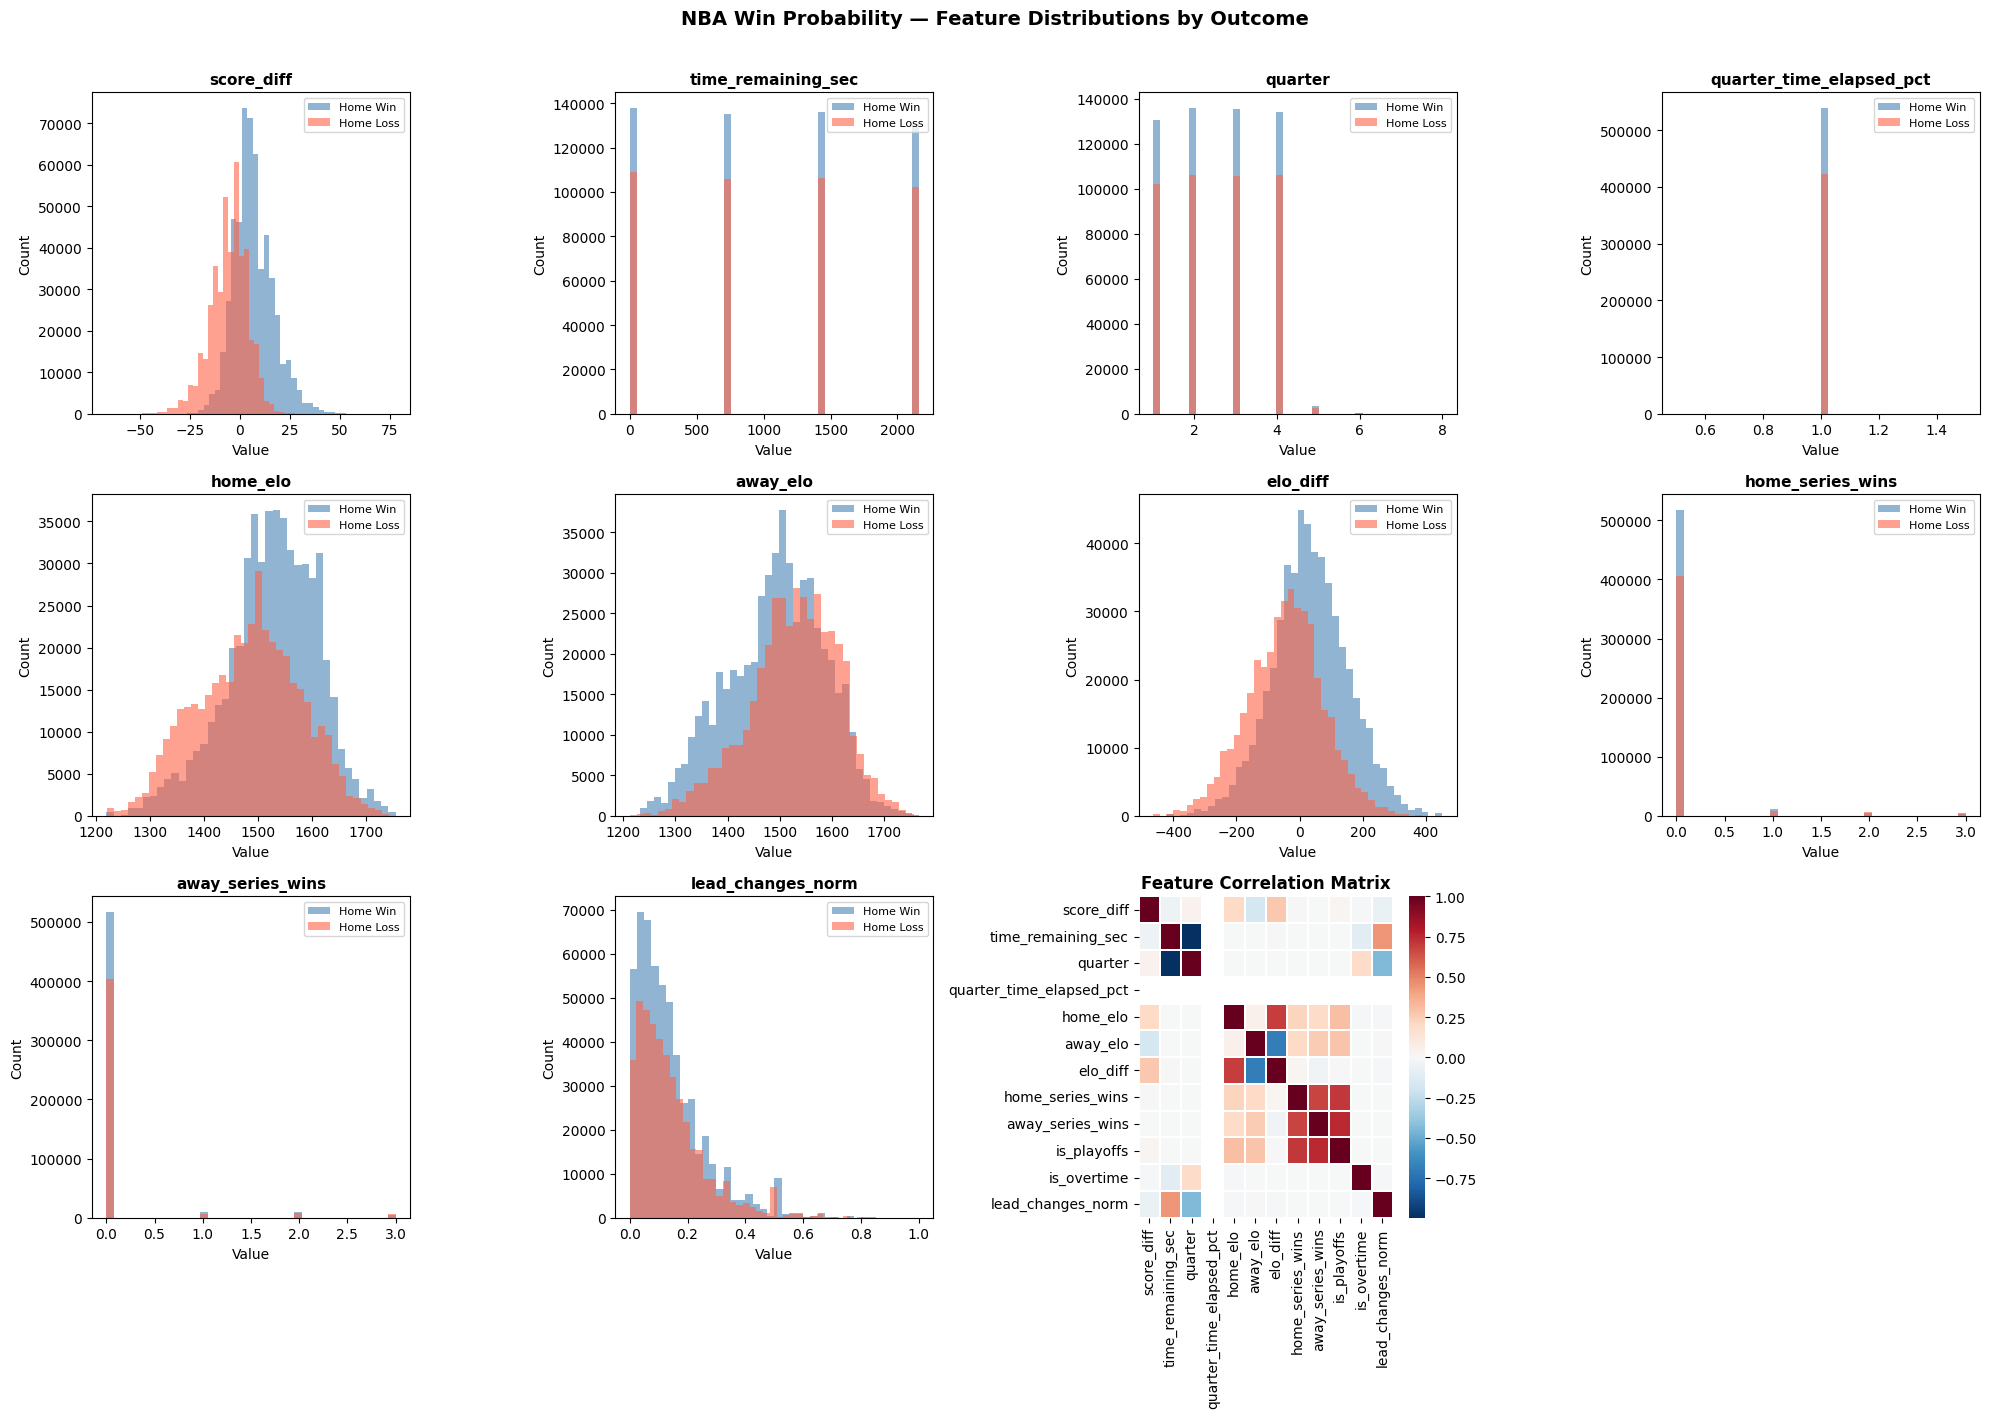

 Saved to nba_win_prob\processed\feature_distributions.png


In [63]:
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

continuous_features = [
    'score_diff', 'time_remaining_sec', 'quarter',
    'quarter_time_elapsed_pct', 'home_elo', 'away_elo',
    'elo_diff', 'home_series_wins', 'away_series_wins',
    'lead_changes_norm',
]

for i, col in enumerate(continuous_features):
    ax = axes[i]
    win  = features_df[features_df[TARGET_COL] == 1][col]
    lose = features_df[features_df[TARGET_COL] == 0][col]
    ax.hist(win,  bins=40, alpha=0.6, color='steelblue',  label='Home Win')
    ax.hist(lose, bins=40, alpha=0.6, color='tomato',     label='Home Loss')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

# Correlation heatmap in last axis
corr_ax = axes[len(continuous_features)]
corr = features_df[FEATURE_COLS].corr()
sns.heatmap(corr, ax=corr_ax, cmap='RdBu_r', center=0,
            annot=False, linewidths=0.3, fmt='.1f')
corr_ax.set_title('Feature Correlation Matrix', fontweight='bold')

# Hide unused axis
for j in range(len(continuous_features) + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('NBA Win Probability — Feature Distributions by Outcome',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PROC_DIR / 'feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f' Saved to {PROC_DIR / "feature_distributions.png"}')

## Normalisation & Train/Val/Test Split

In [64]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
import pickle

# Group-aware split (entire games go into one split, no leakage) 
# Train: 2018-19 → 2022-23  |  Val: early 2023-24  |  Test: late 2023-24
# We split by GAME_ID (group) so no game spans two splits.

X = features_df[FEATURE_COLS].values.astype(np.float32)
y = features_df[TARGET_COL].values.astype(np.float32)
groups = features_df['GAME_ID'].values

# First cut: 80% train+val, 20% test
gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_val_idx, test_idx = next(gss_outer.split(X, y, groups))

# Second cut: from train+val, 75% train, 25% val
gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, val_idx = next(gss_inner.split(
    X[train_val_idx], y[train_val_idx], groups[train_val_idx]
))
# Remap back to original indices
train_idx = train_val_idx[train_idx]
val_idx   = train_val_idx[val_idx]

print(f'Train snapshots : {len(train_idx):,}  '
      f'({features_df.iloc[train_idx]["GAME_ID"].nunique():,} games)')
print(f'Val snapshots   : {len(val_idx):,}  '
      f'({features_df.iloc[val_idx]["GAME_ID"].nunique():,} games)')
print(f'Test snapshots  : {len(test_idx):,}  '
      f'({features_df.iloc[test_idx]["GAME_ID"].nunique():,} games)')

# Verify no game is in two splits
assert len(set(groups[train_idx]) & set(groups[val_idx]))  == 0, 'LEAKAGE: train-val'
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0, 'LEAKAGE: train-test'
assert len(set(groups[val_idx])   & set(groups[test_idx])) == 0, 'LEAKAGE: val-test'
print(' No game-level leakage between splits')

# Fit scaler ONLY on train set 
scaler = StandardScaler()
X_train = scaler.fit_transform(X[train_idx]).astype(np.float32)
X_val   = scaler.transform(X[val_idx]).astype(np.float32)
X_test  = scaler.transform(X[test_idx]).astype(np.float32)

y_train = y[train_idx]
y_val   = y[val_idx]
y_test  = y[test_idx]

# Save scaler for use at inference time
with open(MODEL_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f'\n Scaler fitted and saved to {MODEL_DIR / "scaler.pkl"}')
print(f'   Feature means (sample): {scaler.mean_[:4].round(3)}')
print(f'   Feature stds  (sample): {scaler.scale_[:4].round(3)}')

Train snapshots : 578,056  (4,536 games)
Val snapshots   : 192,498  (1,513 games)
Test snapshots  : 192,317  (1,513 games)
 No game-level leakage between splits

 Scaler fitted and saved to nba_win_prob\model\scaler.pkl
   Feature means (sample): [1.210000e+00 1.064135e+03 2.530000e+00 1.000000e+00]
   Feature stds  (sample): [ 11.414 803.906   1.132   1.   ]


## Push Tensors to GPU & Save

In [65]:
def to_gpu(arr: np.ndarray) -> torch.Tensor:
    """Convert numpy array to float32 CUDA tensor on RTX 4060."""
    return torch.from_numpy(arr.astype(np.float32)).to(DEVICE)


# ─ Transfer to GPU 
print('⬆  Pushing tensors to GPU...')

X_train_gpu = to_gpu(X_train)
y_train_gpu = to_gpu(y_train)
X_val_gpu   = to_gpu(X_val)
y_val_gpu   = to_gpu(y_val)
X_test_gpu  = to_gpu(X_test)
y_test_gpu  = to_gpu(y_test)

torch.cuda.synchronize()

# VRAM usage report 
vram_used = torch.cuda.memory_allocated() / 1e9
vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9

print(f'\n All tensors on {DEVICE}')
print(f'   X_train : {tuple(X_train_gpu.shape)}  dtype={X_train_gpu.dtype}')
print(f'   y_train : {tuple(y_train_gpu.shape)}')
print(f'   X_val   : {tuple(X_val_gpu.shape)}')
print(f'   X_test  : {tuple(X_test_gpu.shape)}')
print(f'\n   VRAM used : {vram_used:.2f} GB / {vram_total:.1f} GB '
      f'({vram_used/vram_total*100:.1f}%)')

# Save tensors to disk for Phase 2 (training) 
# Save as CPU tensors (portable) — Phase 2 will reload and push to GPU
tensor_path = PROC_DIR / 'tensors.pt'
torch.save({
    'X_train' : X_train_gpu.cpu(),
    'y_train' : y_train_gpu.cpu(),
    'X_val'   : X_val_gpu.cpu(),
    'y_val'   : y_val_gpu.cpu(),
    'X_test'  : X_test_gpu.cpu(),
    'y_test'  : y_test_gpu.cpu(),
    'feature_cols'   : FEATURE_COLS,
    'target_col'     : TARGET_COL,
    'n_features'     : len(FEATURE_COLS),
    'train_game_ids' : groups[train_idx].tolist(),
    'val_game_ids'   : groups[val_idx].tolist(),
    'test_game_ids'  : groups[test_idx].tolist(),
}, tensor_path)

print(f'\n Tensors saved to {tensor_path}')
print(f'   File size: {tensor_path.stat().st_size / 1e6:.1f} MB')

⬆  Pushing tensors to GPU...

 All tensors on cuda
   X_train : (578056, 12)  dtype=torch.float32
   y_train : (578056,)
   X_val   : (192498, 12)
   X_test  : (192317, 12)

   VRAM used : 0.06 GB / 8.6 GB (0.7%)

 Tensors saved to nba_win_prob\processed\tensors.pt
   File size: 69.3 MB


## Final Summary & Phase 1 Report

In [66]:
print('=' * 60)
print('PHASE 1 COMPLETE — SUMMARY')
print('=' * 60)

print(f"""
 Data collected
   Seasons        : {SEASONS[0]} → {SEASONS[-1]}
   Total games    : {features_df['GAME_ID'].nunique():,}
   Total snapshots: {len(features_df):,}
   Features       : {len(FEATURE_COLS)}

 Splits
   Train          : {len(X_train):,} rows  ({len(set(groups[train_idx])):,} games)
   Val            : {len(X_val):,} rows  ({len(set(groups[val_idx])):,} games)
   Test           : {len(X_test):,} rows  ({len(set(groups[test_idx])):,} games)

 Artifacts saved
   raw/game_logs_all.parquet    — all game logs
   raw/pbp/<game_id>.parquet    — per-game play-by-play
   processed/features_raw.parquet
   processed/tensors.pt         — GPU-ready train/val/test tensors
   model/scaler.pkl             — StandardScaler (fit on train only)
   processed/feature_distributions.png

  GPU
   Device         : {gpu.name}
   VRAM used      : {torch.cuda.memory_allocated()/1e9:.2f} GB / {vram_total:.1f} GB

  Next: Phase 2 — Neural Network Training (phase2_training.ipynb)
""")

# Quick win-prob sanity check:
# At end of game (time=0), score_diff should perfectly predict winner
end_of_game = features_df[features_df['time_remaining_sec'] == 0].copy()
if len(end_of_game) > 0:
    correct = ((end_of_game['score_diff'] > 0) == (end_of_game['home_team_won'] == 1))
    acc = correct.mean()
    print(f' Sanity check — end-of-game prediction accuracy: {acc:.4f} (expect ≈ 1.0)')
else:
    print('  No end-of-game snapshots found (time_remaining_sec = 0)')

PHASE 1 COMPLETE — SUMMARY

 Data collected
   Seasons        : 2018-19 → 2023-24
   Total games    : 7,562
   Total snapshots: 962,871
   Features       : 12

 Splits
   Train          : 578,056 rows  (4,536 games)
   Val            : 192,498 rows  (1,513 games)
   Test           : 192,317 rows  (1,513 games)

 Artifacts saved
   raw/game_logs_all.parquet    — all game logs
   raw/pbp/<game_id>.parquet    — per-game play-by-play
   processed/features_raw.parquet
   processed/tensors.pt         — GPU-ready train/val/test tensors
   model/scaler.pkl             — StandardScaler (fit on train only)
   processed/feature_distributions.png

  GPU
   Device         : NVIDIA GeForce RTX 4060 Laptop GPU
   VRAM used      : 0.06 GB / 8.6 GB

  Next: Phase 2 — Neural Network Training (phase2_training.ipynb)

 Sanity check — end-of-game prediction accuracy: 0.8743 (expect ≈ 1.0)
